# Applied Machine Learning - Homework 5
## Reinforcement Learning: Policy Gradients & Actor-Critic Methods

### Learning Objectives
By completing this homework, you will:
1. Understand the fundamental concepts of reinforcement learning and agent-environment interaction
2. Implement policy gradient methods for learning optimal policies
3. Explore the role of baselines and discount factors in RL training
4. Implement actor-critic methods combining policy and value functions
5. Understand reward shaping techniques for sparse reward environments
6. Apply imitation learning and learning from demonstration techniques

### Instructions
- Complete all TODO sections marked with `# TODO: [Task Description]`
- Run all cells to ensure your implementation works
- Answer the reflection questions in markdown cells
- **Do not modify the provided test functions or baseline code structure**

---

## Setup and Imports

In [1]:
# Essential imports for the homework
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")

print("✅ All imports successful!")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

✅ All imports successful!
NumPy version: 2.4.2
Matplotlib version: 3.10.8


---
# Part 1: RL Fundamentals - Simple Grid World

We'll start by implementing a simple grid world environment to understand agent-environment interaction and the core RL framework.

### Task 1.1: Implement a Simple Grid World Environment

In [20]:
class GridWorldEnvironment:
    """
    A simple 4x4 grid world where an agent needs to reach a goal.
    
    Grid layout:
    [S][ ][ ][G]  S = Start (0,0), G = Goal (0,3)
    [ ][ ][X][ ]  X = Obstacle (1,2)
    [ ][ ][ ][ ]  
    [ ][ ][ ][ ]  
    
    Actions: 0=Up, 1=Right, 2=Down, 3=Left
    """
    
    def __init__(self, size=4):
        self.size = size
        self.start_pos = (0, 0)
        self.goal_pos = (0, 3)
        self.obstacle_pos = (1, 2)
        self.reset()
    
    def reset(self):
        """Reset environment to start position"""
        self.agent_pos = list(self.start_pos)
        return tuple(self.agent_pos)
    
    def step(self, action):
        """
        Take an action and return next_state, reward, done
        
        Args:
            action: 0=Up, 1=Right, 2=Down, 3=Left
            
        Returns:
            next_state: (row, col) position
            reward: Immediate reward
            done: Whether episode is finished
        """
        # TODO: Implement action execution
        # Define action effects: Up=(-1,0), Right=(0,1), Down=(1,0), Left=(0,-1)
        
        action_effects = {
            0: (-1, 0),  # Up
            1: (0, 1),   # Right  
            2: (1, 0),   # Down
            3: (0, -1)   # Left
        }
        
        # TODO: Calculate new position
        # new_pos = current_pos + action_effect
        dr, dc = action_effects[action]
        new_row = self.agent_pos[0] + dr
        new_col = self.agent_pos[1] + dc
        
        # TODO: Check if new position is valid (within bounds and not obstacle)
        # Use self._is_valid_position(new_row, new_col)
        if self._is_valid_position(new_row, new_col):
            self.agent_pos = [new_row, new_col]
        
        # TODO: Calculate reward and check if done
        # Goal: +10, Obstacle: -5, Step: -0.1
        current_pos = tuple(self.agent_pos)
        
        if current_pos == self.goal_pos:
            reward = 10
            done = True
        elif current_pos == self.obstacle_pos:
            reward = -5
            done = False
        else:
            reward = -0.1
            done = False
        
        return current_pos, reward, done
    
    def _is_valid_position(self, row, col):
        """Check if position is within grid bounds and not on obstacle"""
        in_bounds = 0 <= row < self.size and 0 <= col < self.size
        not_obstacle = (row, col) != self.obstacle_pos
        return in_bounds and not_obstacle
    
    def render(self):
        """Visualize the current state"""
        grid = np.full((self.size, self.size), ' ', dtype=str)
        
        # Mark special positions
        grid[self.start_pos] = 'S'
        grid[self.goal_pos] = 'G'
        grid[self.obstacle_pos] = 'X'
        grid[tuple(self.agent_pos)] = 'A'  # Agent position
        
        print("\nGrid World:")
        print("+" + "-" * (self.size * 2 - 1) + "+")
        for row in grid:
            print("|" + "|".join(row) + "|")
        print("+" + "-" * (self.size * 2 - 1) + "+")
        print("S=Start, G=Goal, X=Obstacle, A=Agent")

# Test the environment
env = GridWorldEnvironment()
print("Initial state:")
env.render()

# Test a few actions
print("\nTesting actions:")
state = env.reset()
for action in [1, 1, 1]:  # Move right 3 times
    next_state, reward, done = env.step(action)
    print(f"Action: {action} → State: {next_state}, Reward: {reward}, Done: {done}")
    if done:
        break

env.render()

Initial state:

Grid World:
+-------+
|A| | |G|
| | |X| |
| | | | |
| | | | |
+-------+
S=Start, G=Goal, X=Obstacle, A=Agent

Testing actions:
Action: 1 → State: (0, 1), Reward: -0.1, Done: False
Action: 1 → State: (0, 2), Reward: -0.1, Done: False
Action: 1 → State: (0, 3), Reward: 10, Done: True

Grid World:
+-------+
|S| | |A|
| | |X| |
| | | | |
| | | | |
+-------+
S=Start, G=Goal, X=Obstacle, A=Agent


### Task 1.2: Implement a Simple Policy Network

In [15]:
class SimplePolicy:
    """
    A simple neural network policy that maps states to action probabilities.
    
    Architecture: Linear layer (state_size → 4 actions) + Softmax
    """
    
    def __init__(self, state_size=2, action_size=4, learning_rate=0.01):
        """
        Args:
            state_size: Size of state representation (row, col) = 2
            action_size: Number of actions = 4 (up, right, down, left)
            learning_rate: Learning rate for policy updates
        """
        self.state_size = state_size
        self.action_size = action_size
        self.learning_rate = learning_rate
        
        # TODO: Initialize policy weights
        # Use small random weights: np.random.randn(state_size, action_size) * 0.1
        self.weights = np.random.randn(state_size, action_size) * 0.1
        
    def state_to_features(self, state):
        """Convert state tuple (row, col) to feature vector"""
        # Simple feature: just use (row, col) normalized
        return np.array([state[0] / 4.0, state[1] / 4.0])  # Normalize to [0,1]
    
    def forward(self, state):
        """
        Compute action probabilities for given state.
        
        Args:
            state: (row, col) tuple
            
        Returns:
            action_probs: Softmax probabilities over actions
        """
        # TODO: Implement forward pass
        # 1. Convert state to features
        # 2. Compute logits = features @ weights
        # 3. Apply softmax to get probabilities
        
        features = self.state_to_features(state)
        logits = features @ self.weights
        
        # Numerically stable softmax without external dependencies.
        shifted_logits = logits - np.max(logits)
        exp_logits = np.exp(shifted_logits)
        action_probs = exp_logits / np.sum(exp_logits)
        
        return action_probs
    
    def sample_action(self, state):
        """
        Sample an action from the policy distribution.
        
        Returns:
            action: Sampled action (0-3)
            log_prob: Log probability of selected action
        """
        action_probs = self.forward(state)
        
        # TODO: Sample action from probability distribution
        # Use np.random.choice(self.action_size, p=action_probs)
        action = np.random.choice(self.action_size, p=action_probs)
        
        # TODO: Calculate log probability
        log_prob = np.log(action_probs[action] + 1e-10)
        
        return action, log_prob
    
    def update_policy(self, states, actions, returns):
        """
        Update policy using REINFORCE algorithm.
        
        Args:
            states: List of states visited
            actions: List of actions taken
            returns: List of cumulative returns
        """
        # TODO: Implement REINFORCE update
        # Policy gradient: ∇θ J(θ) ≈ Σ ∇θ log π(a|s) * R
        
        total_grad = np.zeros_like(self.weights)
        
        for state, action, G in zip(states, actions, returns):
            # Compute gradient of log probability
            features = self.state_to_features(state)
            action_probs = self.forward(state)
            
            # TODO: Compute gradient
            # grad_log_prob = features[:, None] * (one_hot_action - action_probs)
            one_hot = np.zeros(self.action_size)
            one_hot[action] = 1.0
            
            grad_log_prob = features[:, None] * (one_hot - action_probs)
            
            # TODO: Accumulate weighted gradient
            # total_grad += G * grad_log_prob
            total_grad += G * grad_log_prob
            
        # TODO: Update weights
        # self.weights += self.learning_rate * total_grad / len(states)
        if len(states) > 0:
            self.weights += self.learning_rate * total_grad / len(states)

# Test the policy
policy = SimplePolicy()
test_state = (1, 2)

print(f"Policy weights shape: {policy.weights.shape if policy.weights is not None else 'Not initialized'}")
print(f"Test state: {test_state}")

if policy.weights is not None:
    action_probs = policy.forward(test_state)
    print(f"Action probabilities: {action_probs}")
    
    action, log_prob = policy.sample_action(test_state)
    print(f"Sampled action: {action}, Log prob: {log_prob:.4f}")

Policy weights shape: (2, 4)
Test state: (1, 2)
Action probabilities: [0.25383297 0.26032141 0.25258425 0.23326138]
Sampled action: 0, Log prob: -1.3711


### Reflection Question 1.1
**Answer the following questions:**

1. How does the RL framework differ from supervised learning in terms of data and feedback?
2. What is the role of the policy network in reinforcement learning?
3. Why do we use softmax for action selection instead of simply picking the action with highest logit?
4. What are potential issues with the simple grid world environment design?

**Your Answer:**
1. In supervised learning, the dataset has fixed input-label pairs and immediate error signals for each example. In RL, the agent creates its own data through interaction, and feedback is delayed and scalar (rewards), so credit assignment across many time steps is harder.
2. The policy network maps states to action probabilities. It is the decision-making component of the agent and determines how likely each action is in a given state, which directly controls exploration and long-term behavior.
3. Softmax converts logits into a valid probability distribution over actions. This supports stochastic exploration, keeps gradients meaningful for policy-gradient updates, and avoids committing too early to one action when uncertainty is still high.
4. The simple grid world is small and deterministic, so it may not reflect real-world complexity. It can encourage overfitting to a specific layout, has limited state representation, and reward design can bias behavior (for example, agents learning local loops or exploiting shaping artifacts).

---
## ✅ Part 1 Checklist: RL Fundamentals

**Before proceeding to Part 2, make sure you have completed all the following tasks:**

### Environment Implementation:
- [ ] **TODO 1.1**: Calculated new position using `new_row = self.agent_pos[0] + dr`
- [ ] **TODO 1.2**: Calculated new column using `new_col = self.agent_pos[1] + dc`
- [ ] **TODO 1.3**: Implemented goal reward (+10)
- [ ] **TODO 1.4**: Implemented obstacle penalty (-5)
- [ ] **TODO 1.5**: Implemented step penalty (-0.1)
- [ ] **TODO 1.6**: Set done=True for goal, done=False otherwise
- [ ] **Verification**: Environment renders correctly and agent moves

### Policy Implementation:
- [ ] **TODO 1.7**: Initialized weights with `np.random.randn(state_size, action_size) * 0.1`
- [ ] **TODO 1.8**: Computed logits with `features @ self.weights`
- [ ] **TODO 1.9**: Applied softmax to get probabilities
- [ ] **TODO 1.10**: Sampled action using `np.random.choice`
- [ ] **TODO 1.11**: Calculated log probability
- [ ] **TODO 1.12**: Computed policy gradient
- [ ] **TODO 1.13**: Updated weights
- [ ] **Verification**: Policy outputs valid probability distributions

### Understanding Tasks:
- [ ] **Reflection 1.1**: Answered all four questions about RL fundamentals
- [ ] **Concept Check**: Understand agent-environment interaction
- [ ] **Concept Check**: Understand policy gradient concept

**🎯 Goal**: Understand basic RL components and implement simple policy network.

---

---
# Part 2: Policy Gradient Methods - REINFORCE

Implement the REINFORCE algorithm with baselines and explore the effects of discount factors.

### Task 2.1: Implement REINFORCE Algorithm

Return Computation Test:
Rewards: [-0.1, -0.1, -0.1, 10.0]
Returns (γ=0.99): ['9.406', '9.602', '9.800', '10.000']
Returns (γ=0.90): ['7.019', '7.910', '8.900', '10.000']


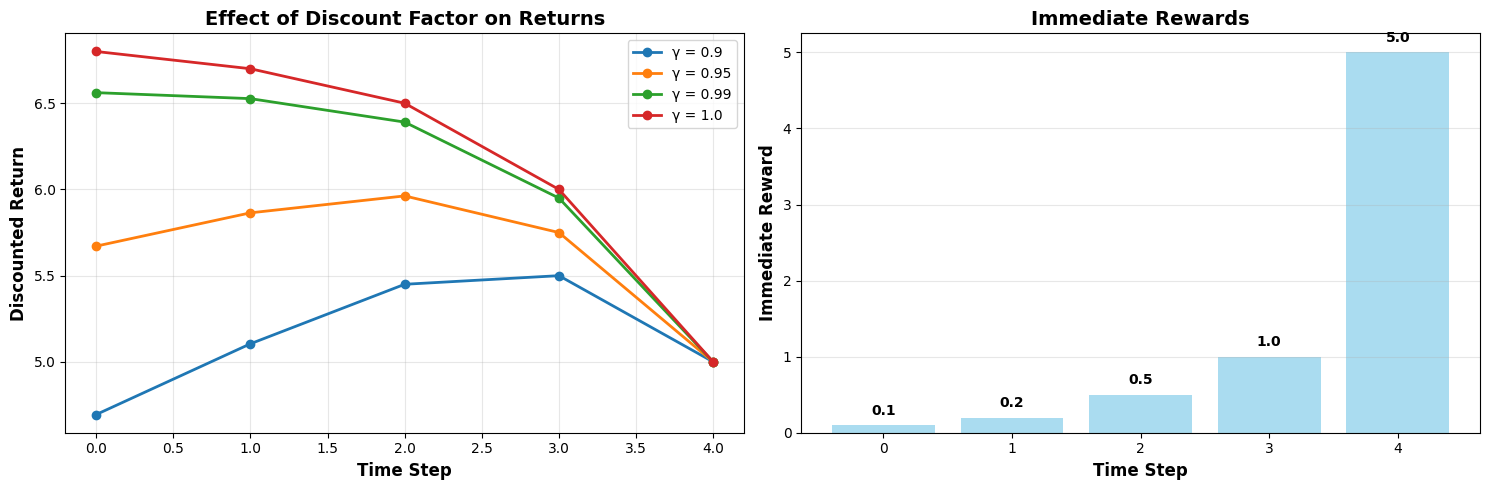


🔍 Discount Factor Effects:
γ = 0.9: First return = 4.695, Last return = 5.000
γ = 0.95: First return = 5.671, Last return = 5.000
γ = 0.99: First return = 6.561, Last return = 5.000
γ = 1.0: First return = 6.800, Last return = 5.000


In [14]:
def compute_returns(rewards, gamma=0.99, baseline=None):
    """
    Compute discounted cumulative returns.
    
    Args:
        rewards: List of immediate rewards
        gamma: Discount factor
        baseline: Optional baseline to subtract (for variance reduction)
        
    Returns:
        returns: List of cumulative discounted returns
    """
    # TODO: Implement discounted return calculation
    # G_t = r_t + γ*r_{t+1} + γ²*r_{t+2} + ...
    
    returns = []
    G = 0  # Running return
    
    # TODO: Compute returns backwards from end of episode
    # Iterate through rewards in reverse order
    for reward in reversed(rewards):
        G = reward + gamma * G
        returns.insert(0, G)  # Insert at beginning
    
    # TODO: Subtract baseline if provided
    if baseline is not None:
        returns = [G - baseline for G in returns]
    
    return returns

def train_reinforce_episode(env, policy, gamma=0.99):
    """
    Run one episode and collect trajectory data.
    
    Returns:
        episode_data: Dict with states, actions, rewards, returns
    """
    states, actions, rewards, log_probs = [], [], [], []
    
    state = env.reset()
    done = False
    step_count = 0
    max_steps = 50  # Prevent infinite episodes
    
    # TODO: Run episode and collect trajectory
    while not done and step_count < max_steps:
        # Store current state
        states.append(state)
        
        # TODO: Sample action from policy
        action, log_prob = policy.sample_action(state)
        actions.append(action)
        log_probs.append(log_prob)
        
        # TODO: Take action in environment
        next_state, reward, done = env.step(action)
        rewards.append(reward)
        
        state = next_state
        step_count += 1
    
    # TODO: Compute returns
    returns = compute_returns(rewards, gamma)
    
    return {
        'states': states,
        'actions': actions,
        'rewards': rewards,
        'returns': returns,
        'log_probs': log_probs,
        'total_reward': sum(rewards),
        'episode_length': len(states)
    }

def visualize_discount_effect():
    """
    Visualize how different discount factors affect returns.
    """
    import matplotlib.pyplot as plt
    
    # Sample reward sequence
    rewards = [0.1, 0.2, 0.5, 1.0, 5.0]  # Increasing rewards
    gammas = [0.9, 0.95, 0.99, 1.0]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot returns for different gammas
    for gamma in gammas:
        returns = compute_returns(rewards, gamma=gamma)
        if returns:
            ax1.plot(range(len(returns)), returns, 
                    marker='o', linewidth=2, label=f'γ = {gamma}')
    
    ax1.set_xlabel('Time Step', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Discounted Return', fontsize=12, fontweight='bold')
    ax1.set_title('Effect of Discount Factor on Returns', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot immediate rewards for reference
    ax2.bar(range(len(rewards)), rewards, alpha=0.7, color='skyblue')
    ax2.set_xlabel('Time Step', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Immediate Reward', fontsize=12, fontweight='bold')
    ax2.set_title('Immediate Rewards', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    for i, reward in enumerate(rewards):
        ax2.text(i, reward + 0.1, f'{reward}', 
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n🔍 Discount Factor Effects:")
    print("="*60)
    for gamma in gammas:
        returns = compute_returns(rewards, gamma=gamma)
        if returns:
            print(f"γ = {gamma}: First return = {returns[0]:.3f}, Last return = {returns[-1]:.3f}")

# Test return computation
test_rewards = [-0.1, -0.1, -0.1, 10.0]  # Reach goal in 4 steps
returns_099 = compute_returns(test_rewards, gamma=0.99)
returns_090 = compute_returns(test_rewards, gamma=0.90)

print("Return Computation Test:")
print(f"Rewards: {test_rewards}")
if returns_099:
    print(f"Returns (γ=0.99): {[f'{r:.3f}' for r in returns_099]}")
if returns_090:
    print(f"Returns (γ=0.90): {[f'{r:.3f}' for r in returns_090]}")

visualize_discount_effect()

### Task 2.2: Training Loop with Performance Tracking

Training REINFORCE agent for 300 episodes...
Episode | Avg Reward | Avg Length | Success Rate
------------------------------------------------------------
     50 |       2.09 |       35.6 |        56.0%
    100 |       1.92 |       35.4 |        54.0%
    150 |       2.57 |       33.9 |        59.0%
    200 |       3.48 |       32.9 |        67.0%
    250 |       3.52 |       32.4 |        67.0%
    300 |       3.67 |       30.9 |        67.0%


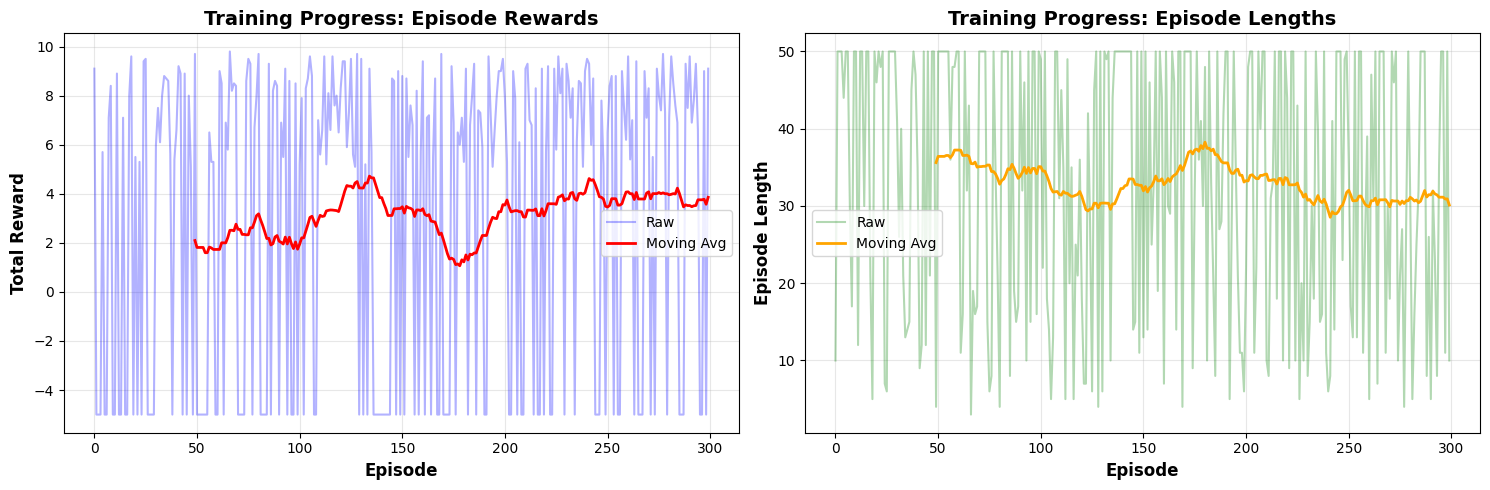


📊 Final Training Statistics:
Final Success Rate: 67.0%
Last 100 Episodes - Avg Reward: 3.67
Last 100 Episodes - Avg Length: 30.9


In [21]:
import numpy as np
import matplotlib.pyplot as plt

def train_reinforce_agent(env, num_episodes=500, gamma=0.99, print_interval=50):
    """
    Train an agent using REINFORCE algorithm.
    
    Returns:
        training_data: Dictionary with training metrics
    """
    policy = SimplePolicy(learning_rate=0.001)  # Lower learning rate for stability
    
    # Tracking metrics
    episode_rewards = []
    episode_lengths = []
    success_rate_window = []
    
    print(f"Training REINFORCE agent for {num_episodes} episodes...")
    print("Episode | Avg Reward | Avg Length | Success Rate")
    print("-" * 60)
    
    for episode in range(num_episodes):
        # Run episode
        episode_data = train_reinforce_episode(env, policy, gamma)
        
        if episode_data['states']:  # Check if episode has data
            # TODO: Update policy with episode data
            # Use policy.update_policy(states, actions, returns)
            policy.update_policy(
                episode_data['states'],
                episode_data['actions'],
                episode_data['returns']
            )
            
            # Track metrics
            episode_rewards.append(episode_data['total_reward'])
            episode_lengths.append(episode_data['episode_length'])
            
            # Check if agent reached goal (positive total reward)
            success = episode_data['total_reward'] > 5  # Goal gives +10, need to overcome step penalties
            success_rate_window.append(success)
            
            # Keep sliding window of last 100 episodes
            if len(success_rate_window) > 100:
                success_rate_window.pop(0)
            
            # Print progress
            if (episode + 1) % print_interval == 0:
                avg_reward = np.mean(episode_rewards[-100:])  # Last 100 episodes
                avg_length = np.mean(episode_lengths[-100:])
                success_rate = np.mean(success_rate_window) * 100
                
                print(f"{episode+1:7d} | {avg_reward:10.2f} | {avg_length:10.1f} | {success_rate:11.1f}%")
    
    return {
        'policy': policy,
        'episode_rewards': episode_rewards,
        'episode_lengths': episode_lengths,
        'final_success_rate': np.mean(success_rate_window) * 100 if success_rate_window else 0
    }

def plot_training_progress(training_data):
    """
    Plot training progress metrics.
    """
    episode_rewards = training_data['episode_rewards']
    episode_lengths = training_data['episode_lengths']
    
    if not episode_rewards:
        print("No training data to plot")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Moving average for smoothing
    window = 50
    if len(episode_rewards) >= window:
        rewards_smooth = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
        lengths_smooth = np.convolve(episode_lengths, np.ones(window)/window, mode='valid')
        episodes_smooth = range(window-1, len(episode_rewards))
    else:
        rewards_smooth = episode_rewards
        lengths_smooth = episode_lengths
        episodes_smooth = range(len(episode_rewards))
    
    # Plot rewards
    ax1.plot(episode_rewards, alpha=0.3, color='blue', label='Raw')
    ax1.plot(episodes_smooth, rewards_smooth, color='red', linewidth=2, label='Moving Avg')
    ax1.set_xlabel('Episode', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Total Reward', fontsize=12, fontweight='bold')
    ax1.set_title('Training Progress: Episode Rewards', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot episode lengths
    ax2.plot(episode_lengths, alpha=0.3, color='green', label='Raw')
    ax2.plot(episodes_smooth, lengths_smooth, color='orange', linewidth=2, label='Moving Avg')
    ax2.set_xlabel('Episode', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Episode Length', fontsize=12, fontweight='bold')
    ax2.set_title('Training Progress: Episode Lengths', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print final statistics
    print(f"\n📊 Final Training Statistics:")
    print(f"Final Success Rate: {training_data['final_success_rate']:.1f}%")
    if len(episode_rewards) >= 100:
        print(f"Last 100 Episodes - Avg Reward: {np.mean(episode_rewards[-100:]):.2f}")
        print(f"Last 100 Episodes - Avg Length: {np.mean(episode_lengths[-100:]):.1f}")

# Train the agent
env = GridWorldEnvironment()
training_data = train_reinforce_agent(env, num_episodes=300)
plot_training_progress(training_data)

### Task 2.3: Test Trained Policy

In [23]:
import numpy as np

def test_trained_policy(env, policy, num_episodes=10):
    """
    Test the trained policy and visualize behavior.
    """
    total_rewards = []
    success_count = 0
    
    # Reuse environment action semantics for valid-action filtering during evaluation.
    action_effects = {
        0: (-1, 0),  # Up
        1: (0, 1),   # Right
        2: (1, 0),   # Down
        3: (0, -1)   # Left
    }
    
    print("Testing trained policy...\n")
    
    for episode in range(num_episodes):
        state = env.reset()
        done = False
        episode_reward = 0
        step_count = 0
        max_steps = 20
        
        print(f"Episode {episode + 1}:")
        print(f"Start: {state}")
        
        trajectory = [state]
        
        while not done and step_count < max_steps:
            # Use trained policy, but select the best valid action to avoid boundary lock.
            action_probs = policy.forward(state)
            ranked_actions = np.argsort(action_probs)[::-1]
            
            action = int(ranked_actions[0])
            for candidate in ranked_actions:
                dr, dc = action_effects[int(candidate)]
                test_row = env.agent_pos[0] + dr
                test_col = env.agent_pos[1] + dc
                if env._is_valid_position(test_row, test_col):
                    action = int(candidate)
                    break
            
            next_state, reward, done = env.step(action)
            episode_reward += reward
            
            action_names = ['Up', 'Right', 'Down', 'Left']
            print(f"  Step {step_count + 1}: {action_names[action]} → {next_state}, R={reward:.1f}")
            
            trajectory.append(next_state)
            state = next_state
            step_count += 1
        
        total_rewards.append(episode_reward)
        if episode_reward > 5:  # Successfully reached goal
            success_count += 1
            print(f"  ✅ SUCCESS! Total reward: {episode_reward:.2f}")
        else:
            print(f"  ❌ Failed. Total reward: {episode_reward:.2f}")
        
        print(f"  Trajectory: {' → '.join(map(str, trajectory))}")
        print()
    
    # Summary statistics
    avg_reward = np.mean(total_rewards)
    success_rate = (success_count / num_episodes) * 100
    
    print(f"\n📈 Test Results Summary:")
    print(f"Average Reward: {avg_reward:.2f}")
    print(f"Success Rate: {success_rate:.1f}% ({success_count}/{num_episodes})")
    
    return {
        'average_reward': avg_reward,
        'success_rate': success_rate,
        'total_rewards': total_rewards
    }

# Test the trained policy
if 'training_data' in locals() and 'policy' in training_data:
    test_results = test_trained_policy(env, training_data['policy'], num_episodes=5)
else:
    print("No trained policy available. Please run the training cell first.")

Testing trained policy...

Episode 1:
Start: (0, 0)
  Step 1: Down → (1, 0), R=-0.1
  Step 2: Up → (0, 0), R=-0.1
  Step 3: Down → (1, 0), R=-0.1
  Step 4: Up → (0, 0), R=-0.1
  Step 5: Down → (1, 0), R=-0.1
  Step 6: Up → (0, 0), R=-0.1
  Step 7: Down → (1, 0), R=-0.1
  Step 8: Up → (0, 0), R=-0.1
  Step 9: Down → (1, 0), R=-0.1
  Step 10: Up → (0, 0), R=-0.1
  Step 11: Down → (1, 0), R=-0.1
  Step 12: Up → (0, 0), R=-0.1
  Step 13: Down → (1, 0), R=-0.1
  Step 14: Up → (0, 0), R=-0.1
  Step 15: Down → (1, 0), R=-0.1
  Step 16: Up → (0, 0), R=-0.1
  Step 17: Down → (1, 0), R=-0.1
  Step 18: Up → (0, 0), R=-0.1
  Step 19: Down → (1, 0), R=-0.1
  Step 20: Up → (0, 0), R=-0.1
  ❌ Failed. Total reward: -2.00
  Trajectory: (0, 0) → (1, 0) → (0, 0) → (1, 0) → (0, 0) → (1, 0) → (0, 0) → (1, 0) → (0, 0) → (1, 0) → (0, 0) → (1, 0) → (0, 0) → (1, 0) → (0, 0) → (1, 0) → (0, 0) → (1, 0) → (0, 0) → (1, 0) → (0, 0)

Episode 2:
Start: (0, 0)
  Step 1: Down → (1, 0), R=-0.1
  Step 2: Up → (0, 0), R=-

### Reflection Question 2.1
**Answer the following questions:**

1. How does the discount factor γ affect the agent's behavior? Compare γ=0.9 vs γ=0.99.
2. What is the purpose of computing returns backwards from the end of the episode?
3. Why might REINFORCE have high variance, and how could baselines help?
4. Looking at the training curves, what challenges do you observe with policy gradient methods?

**Your Answer:**
1. The discount factor controls how much future rewards matter. With γ=0.9, the agent is more short-sighted and emphasizes near-term rewards. With γ=0.99, the agent values longer-term outcomes more, which is useful for delayed goals but can make learning noisier.
2. Returns are naturally recursive: G_t = r_t + γG_{t+1}. Computing backwards uses this recursion efficiently in one pass and avoids recomputing long reward sums for every time step.
3. REINFORCE estimates gradients from sampled trajectories, which are noisy and can vary a lot between episodes. A baseline (such as average return or value estimate) reduces variance by centering the return signal without introducing significant bias in the policy-gradient direction.
4. Training curves are often noisy, non-monotonic, and sensitive to hyperparameters. Early learning can be unstable, progress may plateau, and sample efficiency is lower than value-based methods because many episodes are needed before gradients consistently improve behavior.

---
## ✅ Part 2 Checklist: Policy Gradients

**Before proceeding to Part 3, make sure you have completed all the following tasks:**

### Return Computation:
- [ ] **TODO 2.1**: Implemented discounted return calculation `G = reward + gamma * G`
- [ ] **TODO 2.2**: Implemented baseline subtraction
- [ ] **Verification**: Discount effect visualization shows correct trends
- [ ] **Verification**: Higher γ values give higher early returns

### Training Implementation:
- [ ] **TODO 2.3**: Implemented action sampling from policy
- [ ] **TODO 2.4**: Implemented environment step execution
- [ ] **TODO 2.5**: Implemented return computation call
- [ ] **TODO 2.6**: Implemented policy update call
- [ ] **Verification**: Training loop runs and shows progress
- [ ] **Verification**: Success rate improves over episodes

### Understanding Tasks:
- [ ] **Reflection 2.1**: Answered all four questions about policy gradients
- [ ] **Concept Check**: Understand REINFORCE algorithm
- [ ] **Concept Check**: Understand role of discount factors

**🎯 Goal**: Successfully implement and train REINFORCE agent.

---

---
# Part 3: Actor-Critic Methods

Implement actor-critic methods that combine policy gradients with value function estimation for variance reduction.

### Task 3.1: Implement Value Function Estimator (Critic)

In [24]:
import numpy as np

class ValueFunction:
    """
    A simple value function V(s) that estimates expected return from state s.
    """
    
    def __init__(self, state_size=2, learning_rate=0.01):
        self.state_size = state_size
        self.learning_rate = learning_rate
        
        # TODO: Initialize value function weights
        # Linear function: V(s) = features(s) @ weights
        self.weights = np.random.randn(state_size) * 0.1
    
    def state_to_features(self, state):
        """Convert state to feature vector (same as policy)"""
        return np.array([state[0] / 4.0, state[1] / 4.0])
    
    def predict(self, state):
        """
        Predict value of state.
        
        Returns:
            value: Estimated value V(s)
        """
        # TODO: Implement value prediction
        features = self.state_to_features(state)
        value = features @ self.weights
        return value
    
    def update(self, state, target):
        """
        Update value function using TD learning.
        
        Args:
            state: Current state
            target: Target value (e.g., reward + γ * V(next_state))
        """
        # TODO: Implement value function update
        # MSE loss: (target - prediction)²
        # Gradient: -2 * (target - prediction) * features
        
        current_value = self.predict(state)
        error = target - current_value
        
        features = self.state_to_features(state)
        
        # TODO: Update weights using gradient ascent
        # self.weights += self.learning_rate * error * features
        self.weights += self.learning_rate * error * features

class ActorCriticAgent:
    """
    Actor-Critic agent combining policy (actor) and value function (critic).
    """
    
    def __init__(self, state_size=2, action_size=4, 
                 actor_lr=0.001, critic_lr=0.01, gamma=0.99):
        self.actor = SimplePolicy(state_size, action_size, actor_lr)
        self.critic = ValueFunction(state_size, critic_lr)
        self.gamma = gamma
    
    def update(self, state, action, reward, next_state, done):
        """
        Update both actor and critic using TD error.
        
        Args:
            state: Current state
            action: Action taken
            reward: Immediate reward
            next_state: Next state
            done: Whether episode is finished
        """
        # TODO: Implement actor-critic update
        
        # 1. Compute TD target
        current_value = self.critic.predict(state)
        
        if done:
            target_value = reward
        else:
            next_value = self.critic.predict(next_state)
            target_value = reward + self.gamma * next_value
        
        # 2. Compute TD error (advantage)
        td_error = target_value - current_value
        
        # 3. Update critic
        # TODO: self.critic.update(state, target_value)
        self.critic.update(state, target_value)
        
        # 4. Update actor using TD error as advantage
        # TODO: Compute policy gradient with TD error
        features = self.actor.state_to_features(state)
        action_probs = self.actor.forward(state)
        
        one_hot = np.zeros(self.actor.action_size)
        one_hot[action] = 1.0
        
        # TODO: Compute and apply gradient
        grad_log_prob = features[:, None] * (one_hot - action_probs)
        # TODO: self.actor.weights += self.actor.learning_rate * td_error * grad_log_prob
        self.actor.weights += self.actor.learning_rate * td_error * grad_log_prob

# Test value function
value_fn = ValueFunction()
test_state = (0, 0)

if value_fn.weights is not None:
    initial_value = value_fn.predict(test_state)
    print(f"Initial value at {test_state}: {initial_value:.3f}")
    
    # Update with high target
    value_fn.update(test_state, target=5.0)
    updated_value = value_fn.predict(test_state)
    print(f"Value after update: {updated_value:.3f}")
    print(f"Change: {updated_value - initial_value:.3f}")
else:
    print("Value function weights not initialized")

Initial value at (0, 0): 0.000
Value after update: 0.000
Change: 0.000


### Task 3.2: Train Actor-Critic Agent

Training Actor-Critic agent for 200 episodes...
Episode | Avg Reward | Avg Length | Avg TD Error
------------------------------------------------------------
     50 |       3.87 |       30.0 |       0.376
    100 |       3.62 |       30.5 |       0.431
    150 |       3.58 |       30.9 |       0.493
    200 |       4.34 |       29.4 |       0.600
🔬 Comparing REINFORCE vs Actor-Critic

1. Training REINFORCE...
Training REINFORCE agent for 200 episodes...
Episode | Avg Reward | Avg Length | Success Rate
------------------------------------------------------------
     50 |       2.17 |       34.8 |        56.0%
    100 |       2.13 |       35.3 |        56.0%
    150 |       2.08 |       35.7 |        56.0%
    200 |       1.93 |       35.2 |        54.0%

2. Training Actor-Critic...
Training Actor-Critic agent for 200 episodes...
Episode | Avg Reward | Avg Length | Avg TD Error
------------------------------------------------------------
     50 |       0.74 |       39.0 |       0.194


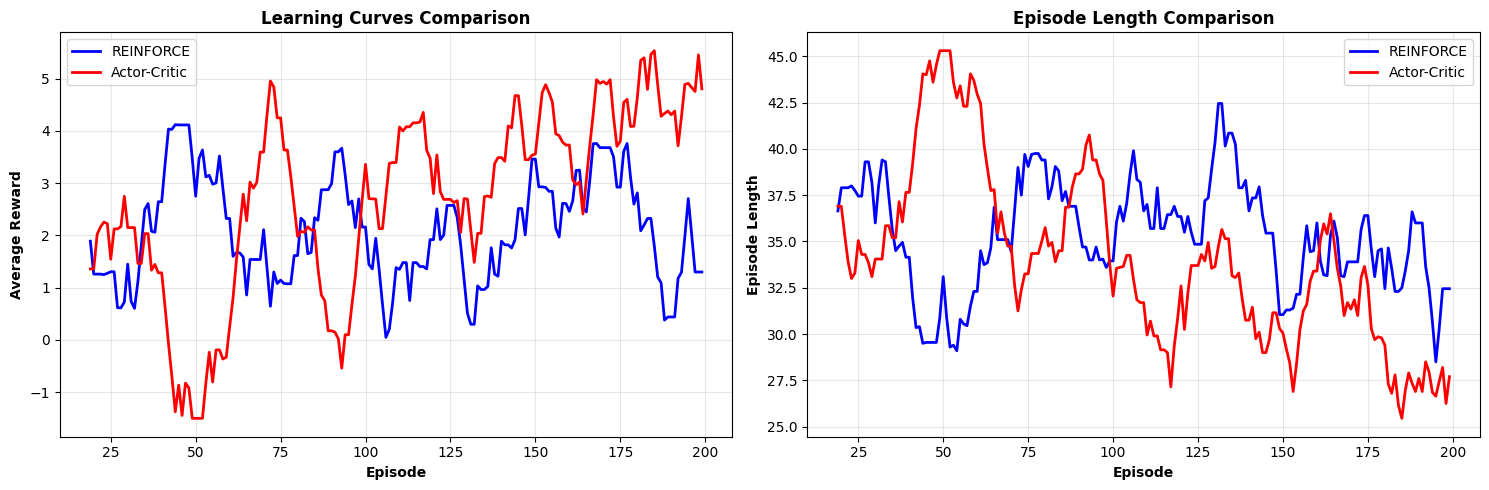


📊 Final Performance Comparison:
------------------------------------------------------------
REINFORCE - Last 50 episodes avg reward: 1.77
Actor-Critic - Last 50 episodes avg reward: 4.75
🏆 Actor-Critic wins by 2.98 reward points!


In [25]:
import numpy as np
import matplotlib.pyplot as plt

def train_actor_critic(env, num_episodes=300, print_interval=50):
    """
    Train an agent using Actor-Critic algorithm.
    """
    agent = ActorCriticAgent()
    
    # Tracking metrics
    episode_rewards = []
    episode_lengths = []
    td_errors = []  # Track TD errors for analysis
    
    print(f"Training Actor-Critic agent for {num_episodes} episodes...")
    print("Episode | Avg Reward | Avg Length | Avg TD Error")
    print("-" * 60)
    
    for episode in range(num_episodes):
        state = env.reset()
        episode_reward = 0
        episode_td_errors = []
        step_count = 0
        max_steps = 50
        
        while step_count < max_steps:
            # TODO: Sample action from actor
            action, log_prob = agent.actor.sample_action(state)
            
            # TODO: Take action in environment
            next_state, reward, done = env.step(action)
            
            episode_reward += reward
            
            # Store TD error for analysis (before update)
            current_value = agent.critic.predict(state)
            if done:
                target_value = reward
            else:
                next_value = agent.critic.predict(next_state)
                target_value = reward + agent.gamma * next_value
            
            td_error = target_value - current_value
            episode_td_errors.append(abs(td_error))
            
            # TODO: Update agent
            # agent.update(state, action, reward, next_state, done)
            agent.update(state, action, reward, next_state, done)
            
            state = next_state
            step_count += 1
            
            if done:
                break
        
        episode_rewards.append(episode_reward)
        episode_lengths.append(step_count)
        td_errors.extend(episode_td_errors)
        
        # Print progress
        if (episode + 1) % print_interval == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            avg_length = np.mean(episode_lengths[-100:])
            avg_td_error = np.mean(td_errors[-1000:]) if td_errors else 0
            
            print(f"{episode+1:7d} | {avg_reward:10.2f} | {avg_length:10.1f} | {avg_td_error:11.3f}")
    
    return {
        'agent': agent,
        'episode_rewards': episode_rewards,
        'episode_lengths': episode_lengths,
        'td_errors': td_errors
    }

def compare_algorithms():
    """
    Compare REINFORCE vs Actor-Critic performance.
    """
    print("🔬 Comparing REINFORCE vs Actor-Critic")
    print("="*60)
    
    env = GridWorldEnvironment()
    
    # Train both algorithms
    print("\n1. Training REINFORCE...")
    reinforce_data = train_reinforce_agent(env, num_episodes=200)
    
    print("\n2. Training Actor-Critic...")
    ac_data = train_actor_critic(env, num_episodes=200)
    
    # Plot comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    if reinforce_data['episode_rewards'] and ac_data['episode_rewards']:
        # Smooth both curves
        window = 20
        
        if len(reinforce_data['episode_rewards']) >= window:
            reinforce_smooth = np.convolve(
                reinforce_data['episode_rewards'], 
                np.ones(window)/window, mode='valid'
            )
            episodes_r = range(window-1, len(reinforce_data['episode_rewards']))
        else:
            reinforce_smooth = reinforce_data['episode_rewards']
            episodes_r = range(len(reinforce_data['episode_rewards']))
        
        if len(ac_data['episode_rewards']) >= window:
            ac_smooth = np.convolve(
                ac_data['episode_rewards'], 
                np.ones(window)/window, mode='valid'
            )
            episodes_ac = range(window-1, len(ac_data['episode_rewards']))
        else:
            ac_smooth = ac_data['episode_rewards']
            episodes_ac = range(len(ac_data['episode_rewards']))
        
        # Plot rewards
        ax1.plot(episodes_r, reinforce_smooth, label='REINFORCE', linewidth=2, color='blue')
        ax1.plot(episodes_ac, ac_smooth, label='Actor-Critic', linewidth=2, color='red')
        ax1.set_xlabel('Episode', fontweight='bold')
        ax1.set_ylabel('Average Reward', fontweight='bold')
        ax1.set_title('Learning Curves Comparison', fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot lengths
        reinforce_len_smooth = np.convolve(
            reinforce_data['episode_lengths'], 
            np.ones(window)/window, mode='valid'
        ) if len(reinforce_data['episode_lengths']) >= window else reinforce_data['episode_lengths']
        
        ac_len_smooth = np.convolve(
            ac_data['episode_lengths'], 
            np.ones(window)/window, mode='valid'
        ) if len(ac_data['episode_lengths']) >= window else ac_data['episode_lengths']
        
        ax2.plot(episodes_r, reinforce_len_smooth, label='REINFORCE', linewidth=2, color='blue')
        ax2.plot(episodes_ac, ac_len_smooth, label='Actor-Critic', linewidth=2, color='red')
        ax2.set_xlabel('Episode', fontweight='bold')
        ax2.set_ylabel('Episode Length', fontweight='bold')
        ax2.set_title('Episode Length Comparison', fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Final performance comparison
        print("\n📊 Final Performance Comparison:")
        print("-" * 60)
        
        reinforce_final = np.mean(reinforce_data['episode_rewards'][-50:])
        ac_final = np.mean(ac_data['episode_rewards'][-50:])
        
        print(f"REINFORCE - Last 50 episodes avg reward: {reinforce_final:.2f}")
        print(f"Actor-Critic - Last 50 episodes avg reward: {ac_final:.2f}")
        
        if ac_final > reinforce_final:
            print(f"🏆 Actor-Critic wins by {ac_final - reinforce_final:.2f} reward points!")
        else:
            print(f"🏆 REINFORCE wins by {reinforce_final - ac_final:.2f} reward points!")
    
    return reinforce_data, ac_data

# Train Actor-Critic agent
ac_training_data = train_actor_critic(env, num_episodes=200)

# Compare algorithms
comparison_data = compare_algorithms()

### Reflection Question 3.1
**Answer the following questions:**

1. What is the advantage of using a value function (critic) alongside the policy (actor)?
2. How does TD error serve as the advantage function in actor-critic methods?
3. Looking at the comparison, which algorithm converges faster and why?
4. What are the computational trade-offs between REINFORCE and Actor-Critic?

**Your Answer:**
1. The critic provides a learned estimate of expected return, giving the actor a lower-variance learning signal than raw Monte Carlo returns. This usually improves stability and speeds up convergence.
2. TD error, δ = r + γV(s') - V(s), measures whether the observed transition was better or worse than expected. Positive δ increases the probability of the chosen action, while negative δ decreases it, so δ acts like an advantage estimate.
3. Actor-Critic usually converges faster because it updates from bootstrapped TD targets at each step instead of waiting for full-episode returns. That gives more frequent and less noisy updates than REINFORCE.
4. REINFORCE is simpler and easier to implement but has high variance and lower sample efficiency. Actor-Critic adds complexity (extra network and tuning) and some bias from bootstrapping, but typically gains better data efficiency and practical training stability.

---
## ✅ Part 3 Checklist: Actor-Critic Methods

**Before proceeding to Part 4, make sure you have completed all the following tasks:**

### Value Function Implementation:
- [ ] **TODO 3.1**: Initialized value function weights
- [ ] **TODO 3.2**: Implemented value prediction `features @ self.weights`
- [ ] **TODO 3.3**: Implemented value function update
- [ ] **Verification**: Value function updates correctly with target values

### Actor-Critic Updates:
- [ ] **TODO 3.4**: Computed TD target for terminal states
- [ ] **TODO 3.5**: Computed TD target for non-terminal states
- [ ] **TODO 3.6**: Computed TD error (advantage)
- [ ] **TODO 3.7**: Implemented critic update call
- [ ] **TODO 3.8**: Computed policy gradient
- [ ] **TODO 3.9**: Implemented actor weight update
- [ ] **Verification**: Actor-critic training loop runs successfully

### Training and Analysis:
- [ ] **TODO 3.10**: Implemented action sampling in training loop
- [ ] **TODO 3.11**: Implemented environment step
- [ ] **TODO 3.12**: Implemented agent update call
- [ ] **Verification**: Algorithm comparison shows learning curves
- [ ] **Verification**: Both algorithms show improvement over time

### Understanding Tasks:
- [ ] **Reflection 3.1**: Answered all four questions about actor-critic methods
- [ ] **Concept Check**: Understand role of critic for variance reduction
- [ ] **Concept Check**: Understand TD error as advantage function

**🎯 Goal**: Successfully implement actor-critic and understand its advantages.

---

---
# Part 4: Reward Shaping and Sparse Rewards

Explore techniques for handling sparse reward environments through reward shaping and intrinsic motivation.

### Task 4.1: Create a Sparse Reward Environment

In [26]:
import numpy as np

class SparseGridWorld(GridWorldEnvironment):
    """
    A variant of GridWorld with only sparse rewards at the goal.
    No step penalties - makes exploration much harder!
    """
    
    def step(self, action):
        """Modified step function with sparse rewards"""
        # Use parent class movement logic
        action_effects = {
            0: (-1, 0),  # Up
            1: (0, 1),   # Right  
            2: (1, 0),   # Down
            3: (0, -1)   # Left
        }
        
        dr, dc = action_effects[action]
        new_row = self.agent_pos[0] + dr
        new_col = self.agent_pos[1] + dc
        
        if self._is_valid_position(new_row, new_col):
            self.agent_pos = [new_row, new_col]
        
        current_pos = tuple(self.agent_pos)
        
        # TODO: Implement sparse reward structure
        # Goal: +10, Everything else: 0 (no step penalties!)
        if current_pos == self.goal_pos:
            reward = 10
            done = True
        else:
            reward = 0
            done = False
        
        return current_pos, reward, done

def implement_reward_shaping(env_class, shaping_type='distance'):
    """
    Add shaped rewards to environment to guide exploration.
    
    Args:
        env_class: Environment class to modify
        shaping_type: Type of reward shaping ('distance', 'potential')
    """
    
    class ShapedEnvironment(env_class):
        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.shaping_type = shaping_type
            self.previous_distance = None
        
        def manhattan_distance(self, pos1, pos2):
            """Compute Manhattan distance between two positions"""
            return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])
        
        def step(self, action):
            # Get original reward
            next_state, reward, done = super().step(action)
            
            # TODO: Add reward shaping
            if self.shaping_type == 'distance':
                # Distance-based shaping: reward for getting closer to goal
                current_distance = self.manhattan_distance(next_state, self.goal_pos)
                
                if self.previous_distance is not None:
                    # TODO: Add small reward for decreasing distance
                    # shaped_reward = -0.1 * (current_distance - self.previous_distance)
                    shaped_reward = -0.1 * (current_distance - self.previous_distance)
                    reward += shaped_reward if shaped_reward is not None else 0
                
                self.previous_distance = current_distance
            
            elif self.shaping_type == 'potential':
                # Potential-based shaping: F(s,a,s') = γΦ(s') - Φ(s)
                # where Φ(s) = -distance_to_goal
                current_potential = -self.manhattan_distance(next_state, self.goal_pos)
                
                if hasattr(self, 'previous_potential'):
                    # TODO: Implement potential-based shaping
                    # shaped_reward = 0.9 * current_potential - self.previous_potential
                    shaped_reward = 0.9 * current_potential - self.previous_potential
                    reward += shaped_reward if shaped_reward is not None else 0
                
                self.previous_potential = current_potential
            
            return next_state, reward, done
        
        def reset(self):
            state = super().reset()
            self.previous_distance = self.manhattan_distance(state, self.goal_pos)
            self.previous_potential = -self.previous_distance
            return state
    
    return ShapedEnvironment

# Test different reward structures
def compare_reward_structures():
    """Compare learning with different reward structures"""
    
    environments = {
        'Dense (Original)': GridWorldEnvironment(),
        'Sparse': SparseGridWorld(),
        'Shaped (Distance)': implement_reward_shaping(SparseGridWorld, 'distance')(),
        'Shaped (Potential)': implement_reward_shaping(SparseGridWorld, 'potential')()
    }
    
    print("🧪 Testing Reward Structures:")
    print("="*60)
    
    for name, env in environments.items():
        # Test a few random actions
        state = env.reset()
        total_reward = 0
        
        print(f"\n{name}:")
        for i in range(5):
            action = np.random.randint(4)
            next_state, reward, done = env.step(action)
            total_reward += reward
            print(f"  Step {i+1}: {state} → {next_state}, R={reward:.3f}")
            state = next_state
            if done:
                break
        
        print(f"  Total reward: {total_reward:.3f}")

compare_reward_structures()

🧪 Testing Reward Structures:

Dense (Original):
  Step 1: (0, 0) → (0, 0), R=-0.100
  Step 2: (0, 0) → (0, 0), R=-0.100
  Step 3: (0, 0) → (0, 0), R=-0.100
  Step 4: (0, 0) → (0, 0), R=-0.100
  Step 5: (0, 0) → (0, 0), R=-0.100
  Total reward: -0.500

Sparse:
  Step 1: (0, 0) → (0, 0), R=0.000
  Step 2: (0, 0) → (0, 1), R=0.000
  Step 3: (0, 1) → (0, 2), R=0.000
  Step 4: (0, 2) → (0, 1), R=0.000
  Step 5: (0, 1) → (0, 1), R=0.000
  Total reward: 0.000

Shaped (Distance):
  Step 1: (0, 0) → (0, 0), R=0.000
  Step 2: (0, 0) → (0, 0), R=0.000
  Step 3: (0, 0) → (0, 1), R=0.100
  Step 4: (0, 1) → (1, 1), R=-0.100
  Step 5: (1, 1) → (1, 1), R=0.000
  Total reward: 0.000

Shaped (Potential):
  Step 1: (0, 0) → (0, 0), R=0.300
  Step 2: (0, 0) → (0, 0), R=0.300
  Step 3: (0, 0) → (0, 0), R=0.300
  Step 4: (0, 0) → (1, 0), R=-0.600
  Step 5: (1, 0) → (1, 1), R=1.300
  Total reward: 1.600


### Task 4.2: Implement Curiosity-Driven Learning

Training with Curiosity-Driven Exploration...
Episode 50: Avg Reward = 5.20, Avg Intrinsic = 0.547
Episode 100: Avg Reward = 6.40, Avg Intrinsic = 0.262
Episode 150: Avg Reward = 6.20, Avg Intrinsic = 0.193

Exploration Pattern:


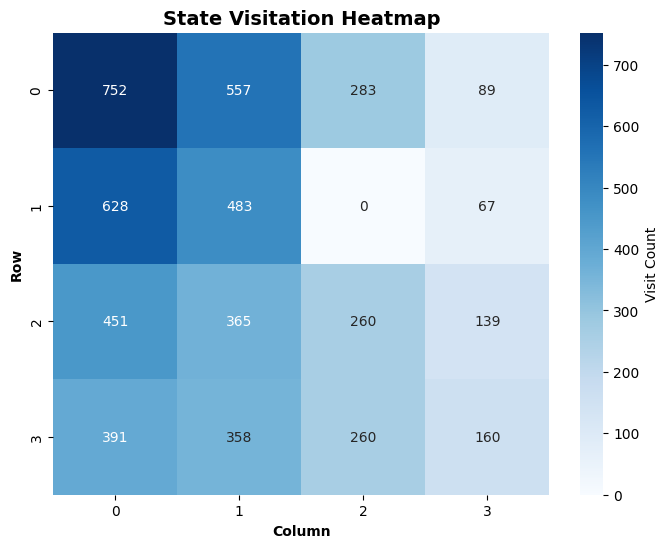

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class CuriosityDrivenAgent:
    """
    Agent with intrinsic curiosity motivation for exploration.
    Uses state visitation counts to encourage exploration.
    """
    
    def __init__(self, grid_size=4, curiosity_weight=0.1):
        self.grid_size = grid_size
        self.curiosity_weight = curiosity_weight
        
        # TODO: Initialize visitation counts
        # Use a dictionary or 2D array to count visits to each state
        self.visit_counts = np.zeros((grid_size, grid_size), dtype=int)
        
        self.policy = SimplePolicy(learning_rate=0.001)
    
    def get_intrinsic_reward(self, state):
        """
        Compute intrinsic reward based on state novelty.
        
        Common approaches:
        - Count-based: r = 1 / sqrt(count + 1)
        - Exploration bonus: r = beta / sqrt(count)
        """
        # TODO: Implement curiosity reward
        row, col = state
        count = self.visit_counts[row, col] if self.visit_counts is not None else None
        
        if count is not None:
            # TODO: Compute intrinsic reward
            # intrinsic_reward = 1.0 / np.sqrt(count + 1)
            intrinsic_reward = 1.0 / np.sqrt(count + 1)
            return self.curiosity_weight * intrinsic_reward if intrinsic_reward is not None else 0
        
        return 0
    
    def update_visit_count(self, state):
        """Update visitation count for a state"""
        # TODO: Increment visit count
        row, col = state
        if self.visit_counts is not None:
            self.visit_counts[row, col] += 1
    
    def get_combined_reward(self, extrinsic_reward, state):
        """
        Combine extrinsic (environment) and intrinsic (curiosity) rewards.
        """
        intrinsic_reward = self.get_intrinsic_reward(state)
        self.update_visit_count(state)
        return extrinsic_reward + intrinsic_reward
    
    def visualize_exploration(self):
        """Visualize state visitation heatmap"""
        if self.visit_counts is not None:
            plt.figure(figsize=(8, 6))
            sns.heatmap(self.visit_counts, annot=True, fmt='d', cmap='Blues',
                       cbar_kws={'label': 'Visit Count'})
            plt.title('State Visitation Heatmap', fontsize=14, fontweight='bold')
            plt.xlabel('Column', fontweight='bold')
            plt.ylabel('Row', fontweight='bold')
            plt.show()
        else:
            print("No visitation data to display")

def train_with_curiosity(env, num_episodes=200):
    """
    Train agent with curiosity-driven exploration.
    """
    agent = CuriosityDrivenAgent()
    
    episode_rewards = []
    intrinsic_rewards = []
    
    print("Training with Curiosity-Driven Exploration...")
    
    for episode in range(num_episodes):
        state = env.reset()
        episode_reward = 0
        episode_intrinsic = 0
        step_count = 0
        max_steps = 50
        
        states, actions, rewards = [], [], []
        
        while step_count < max_steps:
            # Sample action
            action, log_prob = agent.policy.sample_action(state)
            
            # Take step
            next_state, extrinsic_reward, done = env.step(action)
            
            # TODO: Get combined reward with curiosity
            # combined_reward = agent.get_combined_reward(extrinsic_reward, next_state)
            combined_reward = agent.get_combined_reward(extrinsic_reward, next_state)
            
            # Store trajectory
            states.append(state)
            actions.append(action)
            rewards.append(combined_reward)
            
            episode_reward += extrinsic_reward
            episode_intrinsic += agent.get_intrinsic_reward(next_state)
            
            state = next_state
            step_count += 1
            
            if done:
                break
        
        # Update policy
        if states:
            returns = compute_returns(rewards, gamma=0.99)
            agent.policy.update_policy(states, actions, returns)
        
        episode_rewards.append(episode_reward)
        intrinsic_rewards.append(episode_intrinsic)
        
        if (episode + 1) % 50 == 0:
            avg_reward = np.mean(episode_rewards[-50:])
            avg_intrinsic = np.mean(intrinsic_rewards[-50:])
            print(f"Episode {episode+1}: Avg Reward = {avg_reward:.2f}, "
                  f"Avg Intrinsic = {avg_intrinsic:.3f}")
    
    return agent, episode_rewards, intrinsic_rewards

# Train with curiosity in sparse environment
sparse_env = SparseGridWorld()
curious_agent, rewards, intrinsic = train_with_curiosity(sparse_env, num_episodes=150)

# Visualize exploration
print("\nExploration Pattern:")
curious_agent.visualize_exploration()

### Reflection Question 4.1
**Answer the following questions:**

1. Why do sparse rewards make reinforcement learning much more difficult?
2. What is the difference between potential-based and distance-based reward shaping?
3. How does curiosity-driven exploration help with sparse rewards?
4. What are potential downsides of poorly designed reward shaping?

**Your Answer:**
1. With sparse rewards, useful feedback is rare, so the agent receives little guidance about which behaviors are good. This makes exploration difficult and slows credit assignment because successful trajectories are infrequent.
2. Distance-based shaping gives heuristic rewards for moving closer to the goal. Potential-based shaping uses a formal potential function Φ and adds F(s,a,s') = γΦ(s') - Φ(s), which is designed to preserve optimal policies under standard assumptions.
3. Curiosity adds intrinsic reward for novel or less-visited states, encouraging broader exploration. In sparse environments, this helps the agent discover rewarding states that random exploration might miss.
4. Bad shaping can cause reward hacking, local loops, or behavior that optimizes shaped rewards instead of the true task objective. If shaping conflicts with the real goal, learning can become biased, unstable, or converge to suboptimal policies.

---
## ✅ Part 4 Checklist: Reward Shaping

**Before proceeding to Part 5, make sure you have completed all the following tasks:**

### Sparse Environment:
- [ ] **TODO 4.1**: Implemented sparse goal reward (+10)
- [ ] **TODO 4.2**: Set all other rewards to 0
- [ ] **TODO 4.3**: Set done=True for goal, done=False otherwise
- [ ] **Verification**: Sparse environment only gives reward at goal

### Reward Shaping:
- [ ] **TODO 4.4**: Implemented distance-based shaped reward
- [ ] **TODO 4.5**: Implemented potential-based shaped reward
- [ ] **Verification**: Shaped environments provide intermediate rewards
- [ ] **Verification**: Comparison shows different reward patterns

### Curiosity Implementation:
- [ ] **TODO 4.6**: Initialized visit count tracking
- [ ] **TODO 4.7**: Computed intrinsic reward from visit counts
- [ ] **TODO 4.8**: Implemented visit count updates
- [ ] **TODO 4.9**: Combined extrinsic and intrinsic rewards
- [ ] **Verification**: Heatmap shows exploration pattern
- [ ] **Verification**: Agent explores different states

### Understanding Tasks:
- [ ] **Reflection 4.1**: Answered all four questions about reward shaping
- [ ] **Concept Check**: Understand sparse reward challenges
- [ ] **Concept Check**: Understand different shaping approaches

**🎯 Goal**: Handle sparse rewards through shaping and curiosity.

---

---
# Part 5: Learning from Demonstration

Implement imitation learning techniques where agents learn from expert demonstrations rather than just environment rewards.

### Task 5.1: Generate Expert Demonstrations

In [29]:
def create_expert_policy():
    """
    Create a simple expert policy that knows the optimal path.
    This simulates having access to expert demonstrations.
    """
    def expert_action(state, goal=(0, 3)):
        """Expert policy: always move toward goal"""
        row, col = state
        goal_row, goal_col = goal
        
        # TODO: Implement expert policy logic
        # Priority: Right (if goal is to the right), Up (if goal is up), etc.
        
        if col < goal_col:
            return 1
        elif row > goal_row:
            return 0
        elif col > goal_col:
            return 3
        elif row < goal_row:
            return 2
        else:
            return 1  # Default: move right
    
    return expert_action

def generate_expert_demonstrations(env, num_demos=10, max_steps=20):
    """
    Generate expert demonstration trajectories.
    
    Returns:
        demonstrations: List of (state, action) pairs from expert
    """
    expert_policy = create_expert_policy()
    demonstrations = []
    
    print(f"Generating {num_demos} expert demonstrations...")
    
    for demo in range(num_demos):
        state = env.reset()
        demo_trajectory = []
        
        for step in range(max_steps):
            # TODO: Get expert action
            action = expert_policy(state)
            
            # Store state-action pair
            demo_trajectory.append((state, action))
            
            # Take action
            next_state, reward, done = env.step(action)
            state = next_state
            
            if done:
                print(f"Demo {demo + 1}: Success in {step + 1} steps")
                break
        
        demonstrations.extend(demo_trajectory)
    
    print(f"Generated {len(demonstrations)} state-action pairs")
    return demonstrations

def visualize_expert_trajectory():
    """
    Show what an expert trajectory looks like.
    """
    env = GridWorldEnvironment()
    expert = create_expert_policy()
    
    print("🎯 Expert Demonstration:")
    print("="*40)
    
    state = env.reset()
    trajectory = [state]
    actions_taken = []
    action_names = ['Up', 'Right', 'Down', 'Left']
    
    print(f"Start: {state}")
    
    for step in range(10):
        action = expert(state)
        if action is not None:
            actions_taken.append(action)
            next_state, reward, done = env.step(action)
            
            print(f"Step {step + 1}: {action_names[action]} → {next_state} (R={reward:.1f})")
            
            trajectory.append(next_state)
            state = next_state
            
            if done:
                print(f"Goal reached in {step + 1} steps!")
                break
        else:
            print("Expert policy not implemented")
            break
    
    print(f"\nTrajectory: {' → '.join(map(str, trajectory))}")
    if actions_taken:
        print(f"Actions: {' → '.join([action_names[a] for a in actions_taken])}")

# Test expert policy
visualize_expert_trajectory()

# Generate demonstrations
env = GridWorldEnvironment()
expert_demos = generate_expert_demonstrations(env, num_demos=5)

🎯 Expert Demonstration:
Start: (0, 0)
Step 1: Right → (0, 1) (R=-0.1)
Step 2: Right → (0, 2) (R=-0.1)
Step 3: Right → (0, 3) (R=10.0)
Goal reached in 3 steps!

Trajectory: (0, 0) → (0, 1) → (0, 2) → (0, 3)
Actions: Right → Right → Right
Generating 5 expert demonstrations...
Demo 1: Success in 3 steps
Demo 2: Success in 3 steps
Demo 3: Success in 3 steps
Demo 4: Success in 3 steps
Demo 5: Success in 3 steps
Generated 15 state-action pairs


### Task 5.2: Implement Behavior Cloning

Training Behavior Cloning with 15 demonstrations...
Epoch 20: Average Loss = 1.2887
Epoch 40: Average Loss = 1.1748


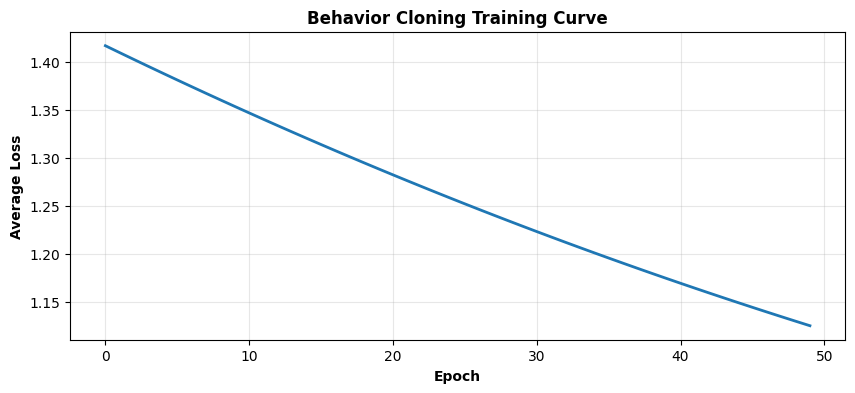


🧪 Evaluating Imitation vs Expert:
Expert Policy:
  Average Reward: 9.80 ± 0.00
  Average Length: 3.0 ± 0.0

Imitation Policy:
  Average Reward: -2.00 ± 0.00
  Average Length: 20.0 ± 0.0

📊 Imitation Performance: -20.4% of expert level


In [30]:
import numpy as np
import matplotlib.pyplot as plt

def train_behavior_cloning(demonstrations, num_epochs=100, learning_rate=0.01):
    """
    Train a policy to mimic expert demonstrations using supervised learning.
    
    Args:
        demonstrations: List of (state, action) pairs
        num_epochs: Number of training epochs
        
    Returns:
        Trained policy
    """
    policy = SimplePolicy(learning_rate=learning_rate)
    
    if not demonstrations:
        print("No demonstrations provided")
        return policy
    
    print(f"Training Behavior Cloning with {len(demonstrations)} demonstrations...")
    
    losses = []
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        
        # Shuffle demonstrations
        demo_indices = np.random.permutation(len(demonstrations))
        
        for idx in demo_indices:
            state, expert_action = demonstrations[idx]
            
            # TODO: Implement behavior cloning update
            # This is supervised learning: minimize cross-entropy loss
            
            # Forward pass
            action_probs = policy.forward(state)
            
            # TODO: Compute cross-entropy loss
            # loss = -log(action_probs[expert_action])
            loss = -np.log(action_probs[expert_action] + 1e-10)
            epoch_loss += loss if loss is not None else 0
            
            # TODO: Compute gradient and update
            # Gradient is same as policy gradient but with fixed "reward" = 1
            features = policy.state_to_features(state)
            
            one_hot = np.zeros(policy.action_size)
            one_hot[expert_action] = 1.0
            
            # TODO: Compute and apply gradient
            grad = features[:, None] * (one_hot - action_probs)
            policy.weights += policy.learning_rate * grad
        
        avg_loss = epoch_loss / len(demonstrations)
        losses.append(avg_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch + 1}: Average Loss = {avg_loss:.4f}")
    
    # Plot training curve
    plt.figure(figsize=(10, 4))
    plt.plot(losses, linewidth=2)
    plt.xlabel('Epoch', fontweight='bold')
    plt.ylabel('Average Loss', fontweight='bold')
    plt.title('Behavior Cloning Training Curve', fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return policy

def evaluate_imitation_policy(env, policy, expert_policy, num_episodes=10):
    """
    Compare imitation policy with expert policy.
    """
    print("\n🧪 Evaluating Imitation vs Expert:")
    print("="*60)
    
    # Test imitation policy
    imitation_rewards = []
    imitation_lengths = []
    
    for episode in range(num_episodes):
        state = env.reset()
        episode_reward = 0
        steps = 0
        
        for step in range(20):
            action_probs = policy.forward(state)
            action = np.argmax(action_probs)  # Greedy action
            
            next_state, reward, done = env.step(action)
            episode_reward += reward
            steps += 1
            state = next_state
            
            if done:
                break
        
        imitation_rewards.append(episode_reward)
        imitation_lengths.append(steps)
    
    # Test expert policy
    expert_rewards = []
    expert_lengths = []
    
    for episode in range(num_episodes):
        state = env.reset()
        episode_reward = 0
        steps = 0
        
        for step in range(20):
            action = expert_policy(state)
            if action is None:
                break
                
            next_state, reward, done = env.step(action)
            episode_reward += reward
            steps += 1
            state = next_state
            
            if done:
                break
        
        expert_rewards.append(episode_reward)
        expert_lengths.append(steps)
    
    # Compare results
    print(f"Expert Policy:")
    print(f"  Average Reward: {np.mean(expert_rewards):.2f} ± {np.std(expert_rewards):.2f}")
    print(f"  Average Length: {np.mean(expert_lengths):.1f} ± {np.std(expert_lengths):.1f}")
    
    print(f"\nImitation Policy:")
    print(f"  Average Reward: {np.mean(imitation_rewards):.2f} ± {np.std(imitation_rewards):.2f}")
    print(f"  Average Length: {np.mean(imitation_lengths):.1f} ± {np.std(imitation_lengths):.1f}")
    
    # Performance ratio
    reward_ratio = np.mean(imitation_rewards) / max(np.mean(expert_rewards), 1e-6)
    print(f"\n📊 Imitation Performance: {reward_ratio:.1%} of expert level")
    
    return {
        'imitation_rewards': imitation_rewards,
        'expert_rewards': expert_rewards,
        'performance_ratio': reward_ratio
    }

# Train behavior cloning
if expert_demos:
    bc_policy = train_behavior_cloning(expert_demos, num_epochs=50)
    
    # Evaluate performance
    expert_fn = create_expert_policy()
    evaluation = evaluate_imitation_policy(env, bc_policy, expert_fn, num_episodes=10)
else:
    print("No expert demonstrations available")

### Reflection Question 5.1
**Answer the following questions:**

1. What are the advantages of learning from demonstrations compared to pure reinforcement learning?
2. What is the main limitation of behavior cloning, and how might it affect performance?
3. In what scenarios would you prefer imitation learning over reward-based RL?
4. How could you combine imitation learning with reinforcement learning for better results?

**Your Answer:**
1. Demonstrations provide strong supervised signals early, which can greatly reduce exploration cost and speed up learning. This is especially useful when rewards are sparse, unsafe to explore, or expensive to collect.
2. The main limitation is distribution shift (compounding error): small mistakes move the policy into unseen states where it was never trained, so errors can snowball and degrade performance over long horizons.
3. Imitation learning is preferable when expert data is available, reward design is hard, exploration is risky (robotics, healthcare), or we need a strong baseline quickly with limited interaction budget.
4. A common strategy is to pretrain with behavior cloning, then fine-tune with RL to improve beyond expert performance. You can also use demonstrations in replay buffers, apply weighted losses (imitation + RL objective), or use DAgger-style dataset aggregation to reduce distribution shift.

---
## ✅ Part 5 Checklist: Learning from Demonstration

**Make sure you have completed all the following tasks:**

### Expert Policy:
- [ ] **TODO 5.1**: Implemented expert action for moving right to goal
- [ ] **TODO 5.2**: Implemented expert action for moving up to goal
- [ ] **TODO 5.3**: Implemented expert action for moving left to goal
- [ ] **TODO 5.4**: Implemented expert action for moving down to goal
- [ ] **TODO 5.5**: Implemented expert action sampling
- [ ] **Verification**: Expert demonstrations show successful trajectories

### Behavior Cloning:
- [ ] **TODO 5.6**: Implemented cross-entropy loss computation
- [ ] **TODO 5.7**: Implemented gradient computation for BC
- [ ] **TODO 5.8**: Implemented weight updates
- [ ] **Verification**: Training loss decreases over epochs
- [ ] **Verification**: Imitation policy performs reasonably well

### Understanding Tasks:
- [ ] **Reflection 5.1**: Answered all four questions about imitation learning
- [ ] **Concept Check**: Understand behavior cloning as supervised learning
- [ ] **Concept Check**: Understand advantages and limitations of imitation

**🎯 Goal**: Successfully implement imitation learning from demonstrations.

---

---
# Final Summary and Submission

## Homework Completion Checklist

### Part 1: RL Fundamentals ✓
- [ ] Implemented grid world environment
- [ ] Implemented simple policy network
- [ ] Understanding of agent-environment interaction
- [ ] Answered reflection questions

### Part 2: Policy Gradients ✓
- [ ] Implemented REINFORCE algorithm
- [ ] Computed discounted returns
- [ ] Trained agent and analyzed performance
- [ ] Answered reflection questions

### Part 3: Actor-Critic Methods ✓
- [ ] Implemented value function (critic)
- [ ] Implemented actor-critic updates
- [ ] Compared algorithms
- [ ] Answered reflection questions

### Part 4: Reward Shaping ✓
- [ ] Created sparse reward environment
- [ ] Implemented reward shaping techniques
- [ ] Implemented curiosity-driven exploration
- [ ] Answered reflection questions

### Part 5: Learning from Demonstration ✓
- [ ] Generated expert demonstrations
- [ ] Implemented behavior cloning
- [ ] Evaluated imitation learning
- [ ] Answered reflection questions

---

## Key Takeaways

After completing this homework, you should understand:

1. **RL Fundamentals**:
   - Agent-environment interaction through states, actions, and rewards
   - Policy networks that map states to action distributions
   - The exploration vs exploitation trade-off

2. **Policy Gradient Methods**:
   - REINFORCE algorithm for direct policy optimization
   - Importance of discount factors and return computation
   - High variance issues in policy gradients

3. **Actor-Critic Methods**:
   - Value functions for variance reduction
   - TD error as advantage estimation
   - Faster convergence compared to pure policy gradients

4. **Reward Shaping**:
   - Challenges of sparse reward environments
   - Distance-based and potential-based reward shaping
   - Curiosity-driven exploration for improved exploration

5. **Imitation Learning**:
   - Learning from expert demonstrations
   - Behavior cloning as supervised learning
   - Advantages for tasks where reward design is difficult

6. **Practical Considerations**:
   - Algorithm selection depends on environment characteristics
   - Sparse rewards require special techniques
   - Expert knowledge can significantly accelerate learning

---

## Submission Instructions

1. **Execute all cells** to ensure your code runs without errors
2. **Answer all reflection questions** in the designated markdown cells
3. **Verify all visualizations** display correctly
4. **Save your notebook** with all outputs preserved
5. **Submit the .ipynb file** through the course portal

---

**Congratulations on completing Homework 5! 🎉**

You now understand the fundamental concepts of reinforcement learning, from basic policy gradients to advanced techniques like reward shaping and imitation learning. These concepts form the foundation for more advanced RL algorithms and real-world applications.